In [2]:
%matplotlib widget

# Script to test LCI using different contrasts

In [3]:
import numpy as np
import pygimli as pg
import empymod as ep
from scipy.constants import mu_0
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
import sys
sys.path.insert(1, 'src')

from FDEM1D import FDEM1DModelling, LCModelling
from showStitched import showStitchedModels
from Plot import Plot2Datas

# Load true models and true datas

In [112]:
norm = np.array([8, 4, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1, 8, 4, 1])

# Load true models

# model parameters [h_1, sigma_1, sigma_2]
model_true = np.load('models/model_s2_c4_uc.npy')
#model_s1_c2_uc = np.load('models/model_s1_c2_uc.npy')
#model_s1_c3_uc = np.load('models/model_s1_c3_uc.npy')
#model_s1_c4_uc = np.load('models/model_s1_c4_uc.npy')

# Define a start model
model_ini = np.ones_like(model_true)
model_ini[:,0] = model_ini[:,0]*3   # initial thickness h_1
model_ini[:,1] = model_ini[:,1]*0.5 # initial sigma_1
model_ini[:,2] = model_ini[:,2]*0.5 # initial sigma_2

# Load true 3D data

# data parameters ['H2', 'H4', 'H8', 'P2', 'P4', 'P8', 'V2', 'V4', 'V8']
data_true = np.load('data/data_s2_c4_uc_sort.npy')[:40] * norm
#data_s1_c2 = np.load('data/data_s1_c2_uc_sort.npy')[:40]
#data_s1_c3 = np.load('data/data_s1_c3_uc_sort.npy')[:40]
#data_s1_c4 = np.load('data/data_s1_c4_uc_sort.npy')[:40]

In [113]:
# model parameters 

# number of layers
nLayers = np.shape(model_true)[1] -1

# number of measurement positions 
npos = len(data_true)

# Initialize Laterally Constrained Inversion

# L-curve criterion

# Run Inversion

In [114]:
LCI = LCModelling(FDEM1DModelling)

LCI.initJacobian(dataVals=data_true, nLay=nLayers)
LCI.createJacobian(model_ini)
LCI.constraint_matrix(data_true, nLay=nLayers)
LCI.normalization(data_true, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createWeight(data_true, cWeight_1=1, cWeight_2=1, nLay=nLayers)
LCI.createConstraints()

# Set transforms
#transData = pg.trans.TransLog()
transThk = pg.trans.TransLogLU(1,5)
transSig = pg.trans.TransLogLU(10/1000,2000/1000)

LCI.region(1).setTransModel(transThk)
LCI.region(2).setTransModel(transSig)

# Create data vector
data_true_vector = data_true.ravel()
relativeError = np.ones_like(data_true_vector)*1e-3 

# Run inversion
inv = pg.Inversion(LCI)
#inv.dataTrans = transData
model_inv = inv.run(data_true_vector, relativeError, startModel=model_ini.ravel(), verbose=True, lam=0 ) #lam_opt)

Inversion is normalized
Jacobian size: 702 117 720


12/07/24 - 16:39:36 - Core - WARNING - no clear() implemented for:  18MatrixBase_wrapper
12/07/24 - 16:39:36 - pyGIMLi - INFO - Starting inversion.
12/07/24 - 16:39:36 - Core - ERROR - no cWeights defined. You should create constraints matrix first.


cWeights are equal
Constraint cWeight length: 117
CW:  <pygimli.math.matrix.MultLeftMatrix object at 0x7fbcfe5dbf60>
min/max(dweight) = 691.285/11835.3
fop: <FDEM1D.LCModelling object at 0x7fbcfe5db100>
Data transformation: <pgcore._pygimli_.RTrans object at 0x7fbd01628820>
Model transformation (cumulative):
	 0 <pgcore._pygimli_.RTransLogLU object at 0x7fbd11e0c7c0>
	 1 <pgcore._pygimli_.RTransLogLU object at 0x7fbd11e0c680>
min/max (data): 0.08/1.45
min/max (error): 0.1%/0.1%
min/max (start model): 0.5/3
--------------------------------------------------------------------------------
use model trans from RegionManager
min/max(dweight) = 691.285/11835.3
 found valid constraints matrix. omit rebuild
constraint matrix of size(nBounds x nModel) 117 x 120
inv.iter 0 ... chi² = 390401.50Calculating Jacobian matrix (forced=1)...... 0.735358 s

--------------------------------------------------------------------------------
inv.iter 1 ... min data = 0.0844931 max data = 1.44658 (720)
min err

# Compare results of inversion

<Axes: title={'center': 'Estimated Model LCI'}>

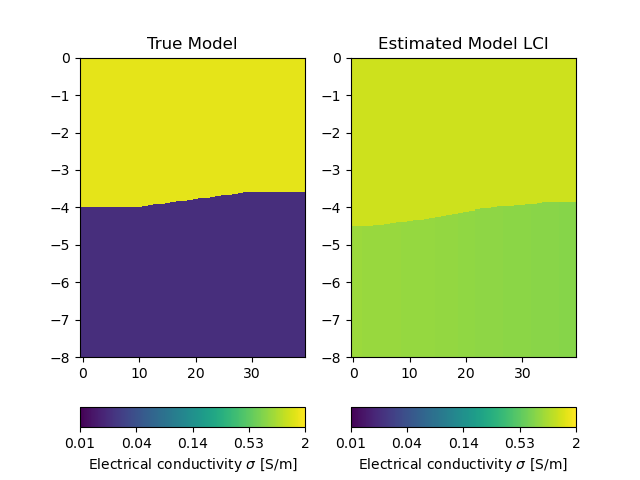

In [115]:
model_inv = np.array(model_inv).reshape(np.shape(model_true))

fig, ax = plt.subplots(1,2)

inputs ={'label' : 'Electrical conductivity $\sigma$ [S/m]',
         'cMin': 10/1000,
         'cMax': 2000/1000, 
         'logScale':True, 
         'location':'right'}

showStitchedModels(ax = ax[0], models=model_true, zMax=8, 
                  title = 'True Model', **inputs)

showStitchedModels(ax = ax[1], models=model_inv, zMax=8, 
                  title = 'Estimated Model LCI', **inputs)

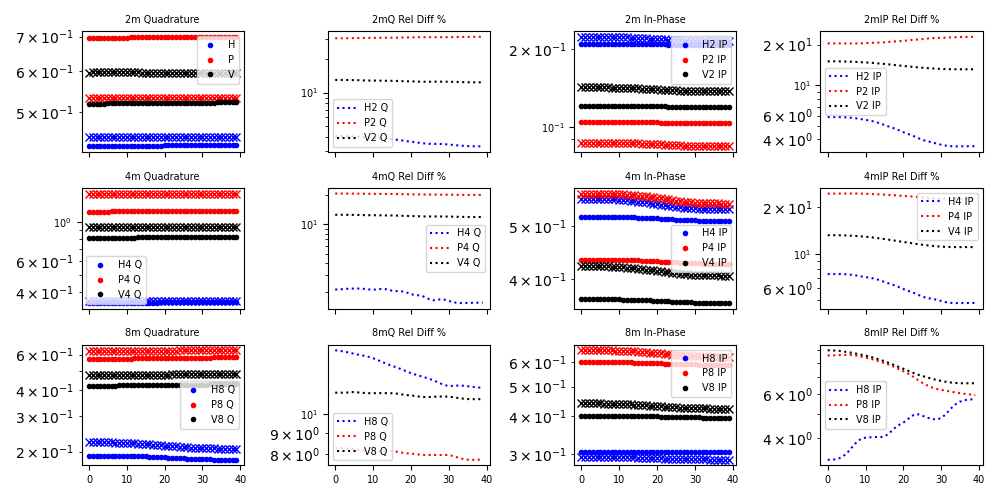

In [116]:
# Compare data

data_inv = np.array(inv.response)
data_inv = data_inv.reshape(np.shape(data_true))

Plot2Datas(data_inv, data_true)

# Store inversion results

In [117]:
np.save('results/model_inv_s2_c4_uc', model_inv)
np.save('results/data_inv_s2_c4_uc', data_inv)